In [1]:
# upload data to HDFS
!hdfs dfs -D dfs.replication=1 -cp -f data/*.jsonl hdfs://nn:9000/
!hdfs dfs -D dfs.replication=1 -cp -f data/*.csv hdfs://nn:9000/

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("cs544")
    .master("spark://boss:7077")
    .config("spark.executor.memory", "1G")
    .config("spark.sql.warehouse.dir", "hdfs://nn:9000/user/hive/warehouse")
    .enableHiveSupport()
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/16 03:43:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
problems_df = spark.read.json("hdfs://nn:9000/problems.jsonl")
problems_df.limit(5).show()

[Stage 1:>                                                          (0 + 1) / 1]

+-------------+--------+---------+---------+---------------+----------+---------------+-------------------------+------------------+--------------------+-------------+----------+------------+------+----------+
|cf_contest_id|cf_index|cf_points|cf_rating|        cf_tags|difficulty|generated_tests|is_description_translated|memory_limit_bytes|                name|private_tests|problem_id|public_tests|source|time_limit|
+-------------+--------+---------+---------+---------------+----------+---------------+-------------------------+------------------+--------------------+-------------+----------+------------+------+----------+
|            0|        |      0.0|        0|             []|         1|            100|                    false|                 0|               fsqrt|            0|         1|           1|     1|        -1|
|            0|        |      0.0|        0|             []|         2|            100|                    false|                 0|            codecrck|       

In [4]:
# Load JSON data and save as Hive tables

problems_df = spark.read.json("hdfs://nn:9000/problems.jsonl")
solutions_df = spark.read.json("hdfs://nn:9000/solutions.jsonl")

spark.sql("DROP TABLE IF EXISTS problems")
spark.sql("DROP TABLE IF EXISTS solutions")

problems_df.write.mode("overwrite").saveAsTable("problems")

solutions_df.write \
    .mode("overwrite") \
    .bucketBy(4, "language") \
    .saveAsTable("solutions")

26/07/16 03:44:02 WARN ObjectStore: Version information not found in metastore. hive.metastore.schema.verification is not enabled so recording the schema version 2.3.0
26/07/16 03:44:02 WARN ObjectStore: setMetaStoreSchemaVersion called but recording version is disabled: version = 2.3.0, comment = Set by MetaStore UNKNOWN@172.18.0.5
26/07/16 03:44:04 WARN SessionState: METASTORE_FILTER_HOOK will be ignored, since hive.security.authorization.manager is set to instance of HiveAuthorizerFactory.
26/07/16 03:44:05 WARN HiveConf: HiveConf of name hive.internal.ss.authz.settings.applied.marker does not exist
                                                                                

In [5]:
# Load CSV files as temporary views

for name in ["languages", "problem_tests", "sources", "tags"]:
    df = spark.read.option("header", True).option("inferSchema", True).csv(f"hdfs://nn:9000/{name}.csv")
    df.createOrReplaceTempView(name)

spark.sql("SHOW TABLES").show()

+---------+-------------+-----------+
|namespace|    tableName|isTemporary|
+---------+-------------+-----------+
|  default|     problems|      false|
|  default|    solutions|      false|
|         |    languages|       true|
|         |problem_tests|       true|
|         |      sources|       true|
|         |         tags|       true|
+---------+-------------+-----------+



In [6]:
#q1: How many problems are there with a cf_rating of at least 1600, having private_tests, and a name containing "_A." (Case Sensitive)? Answer using all three Spark APIs.

from pyspark.sql.functions import col

rdd_count = problems_df.rdd.filter(
    lambda row: row.cf_rating >= 1600 and row.private_tests and "_A." in row.name
).count()

dataframe_count = problems_df.filter(
    (col("cf_rating") >= 1600) &
    (col("private_tests") > 0) &
    (col("name").contains("_A."))
).count()

sql_count = spark.sql("""
    SELECT COUNT(*) AS count
    FROM problems
    WHERE cf_rating >= 1600
      AND private_tests > 0
      AND name LIKE '%_A.%'
""").collect()[0]["count"]

(rdd_count, dataframe_count, sql_count)

(217, 217, 217)

In [7]:
#q2: How many correct PYTHON3 solutions are from CODEFORCES?

q2 = spark.sql("""
    SELECT COUNT(*) AS count
    FROM solutions sol
    INNER JOIN problems p
        ON sol.problem_id = p.problem_id
    INNER JOIN sources src
        ON p.source = src.source
    WHERE sol.language = 'PYTHON3'
      AND sol.is_correct = true
      AND src.source_name = 'CODEFORCES'
""").collect()[0]["count"]

q2

10609

In [8]:
#q3: How many problems are of easy/medium/hard difficulty?

q3_rows = spark.sql("""
    SELECT
        CASE
            WHEN difficulty <= 5 THEN 'Easy'
            WHEN difficulty <= 10 THEN 'Medium'
            ELSE 'Hard'
        END AS level,
        COUNT(*) AS count
    FROM problems
    GROUP BY level
""").collect()

q3 = {row["level"]: row["count"] for row in q3_rows}
q3

{'Easy': 409, 'Medium': 5768, 'Hard': 2396}

In [9]:
#q4: What tables/views are in our warehouse?

tables = spark.sql("SHOW TABLES").collect()

q4 = {row["tableName"]: row["isTemporary"] for row in tables}
q4

{'problems': False,
 'solutions': False,
 'languages': True,
 'problem_tests': True,
 'sources': True,
 'tags': True}

In [10]:
#q5: Does the query plan for a GROUP BY on solutions data need to shuffle/exchange rows if the data is pre-bucketed?

q5_df = spark.sql("""
    SELECT language, COUNT(*)
    FROM solutions
    GROUP BY language
""")

q5_df.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[language#298], functions=[count(1)])
   +- HashAggregate(keys=[language#298], functions=[partial_count(1)])
      +- FileScan parquet spark_catalog.default.solutions[language#298] Batched: true, Bucketed: true, DataFilters: [], Format: Parquet, Location: InMemoryFileIndex(1 paths)[hdfs://nn:9000/user/hive/warehouse/solutions], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<language:string>, SelectedBucketsCount: 4 out of 4




In [11]:
#q6: Does caching make it faster to compute averages over a subset of a bigger dataset?

import time
from pyspark.sql.functions import avg

filtered_tests = spark.table("problem_tests").filter("is_generated = false")

def compute_avgs():
    return filtered_tests.select(
        avg("input_chars").alias("avg_input_chars"),
        avg("output_chars").alias("avg_output_chars")
    ).collect()

times = []

start = time.time()
compute_avgs()
times.append(time.time() - start)

filtered_tests.cache()

start = time.time()
compute_avgs()
times.append(time.time() - start)

start = time.time()
compute_avgs()
times.append(time.time() - start)

filtered_tests.unpersist()

times

[0.6258480548858643, 0.8266928195953369, 0.15829920768737793]

In [12]:
# Test Gemini / Vertex AI connection

import os
from google import genai

client = genai.Client(
    vertexai=True,
    project=os.environ["GOOGLE_CLOUD_PROJECT"],
    location="us-central1",
)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="In one sentence, what is a Spark RDD?",
    config={"temperature": 0},
)

print(response.text)

A Spark RDD (Resilient Distributed Dataset) is an immutable, fault-tolerant, distributed collection of elements that can be operated on in parallel across a cluster.


In [13]:
# Part 3: human_query helper

import os
import re
from google import genai

client = genai.Client(
    vertexai=True,
    project=os.environ["GOOGLE_CLOUD_PROJECT"],
    location="us-central1",
)

def human_query(english_question):
    schema_text = """
Available Spark SQL tables/views:

solutions:
- problem_id BIGINT
- language STRING
- is_correct BOOLEAN

problems:
- problem_id BIGINT
- memory_limit_bytes BIGINT
- cf_rating BIGINT
- difficulty BIGINT
- source BIGINT
- name STRING
- private_tests BIGINT
- time_limit BIGINT

sources:
- source INT
- source_name STRING

languages:
- language INT
- language_name STRING

problem_tests:
- problem_id INT
- input_chars INT
- output_chars INT
- is_generated BOOLEAN

tags:
- tag INT
- tag_name STRING
"""

    prompt = f"""
You are writing Spark SQL.

Question:
{english_question}

{schema_text}

Return ONLY one Spark SQL query.
The query must return exactly one row and one numeric column.
Do not include markdown, backticks, explanation, or comments.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt,
        config={"temperature": 0},
    )

    query = response.text.strip()
    query = re.sub(r"^```sql", "", query).replace("```", "").strip()

    result = spark.sql(query).collect()[0][0]
    return int(result)

In [14]:
#q7: How many JAVA solutions are there?

q7 = human_query("How many JAVA solutions are there?")
q7

28722

In [15]:
#q8: What is the maximum memory limit in bytes?

q8 = human_query("What is the maximum memory limit in bytes?")
q8

1024000000

In [16]:
#q9: Do the problems with a missing cf_rating appear more or less challenging than other problems?

from pyspark.sql.functions import col, avg
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor

codeforces_problems = spark.sql("""
    SELECT p.*
    FROM problems p
    INNER JOIN sources s
        ON p.source = s.source
    WHERE s.source_name = 'CODEFORCES'
""")

train = codeforces_problems.filter((col("cf_rating") > 0) & (col("problem_id") % 2 == 0))
test = codeforces_problems.filter((col("cf_rating") > 0) & (col("problem_id") % 2 == 1))
missing = codeforces_problems.filter(col("cf_rating") == 0)

assembler = VectorAssembler(
    inputCols=["difficulty", "time_limit", "memory_limit_bytes"],
    outputCol="features"
)

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="cf_rating",
    maxDepth=5
)

pipeline = Pipeline(stages=[assembler, dt])
model = pipeline.fit(train)

missing_predictions = model.transform(missing)

train_avg = train.select(avg("cf_rating")).collect()[0][0]
test_avg = test.select(avg("cf_rating")).collect()[0][0]
missing_pred_avg = missing_predictions.select(avg("prediction")).collect()[0][0]

(train_avg, test_avg, missing_pred_avg)

(1892.1983983466805, 1888.8102725366875, 1946.5643236388225)

In [17]:
#q10: How does tree depth impact the quality of predictions?

from pyspark.ml.evaluation import RegressionEvaluator
import pandas as pd
import matplotlib.pyplot as plt

evaluator = RegressionEvaluator(
    labelCol="cf_rating",
    predictionCol="prediction",
    metricName="r2"
)

depths = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
rows = []

for depth in depths:
    dt = DecisionTreeRegressor(
        featuresCol="features",
        labelCol="cf_rating",
        maxDepth=depth
    )
    
    pipeline = Pipeline(stages=[assembler, dt])
    model = pipeline.fit(train)
    
    train_pred = model.transform(train)
    test_pred = model.transform(test)
    
    train_r2 = evaluator.evaluate(train_pred)
    test_r2 = evaluator.evaluate(test_pred)
    
    rows.append({
        "depth": depth,
        "train": train_r2,
        "test": test_r2
    })

q10_df = pd.DataFrame(rows)
q10_df

,depth,train,test
0,1,0.425295,0.443233
1,2,0.524881,0.536729
2,3,0.567142,0.576322
3,5,0.598861,0.586147
4,7,0.613504,0.588023
5,10,0.627798,0.577143
6,15,0.632180,0.568314
7,20,0.632342,0.568320
8,25,0.632342,0.568320
9,30,0.632342,0.568320


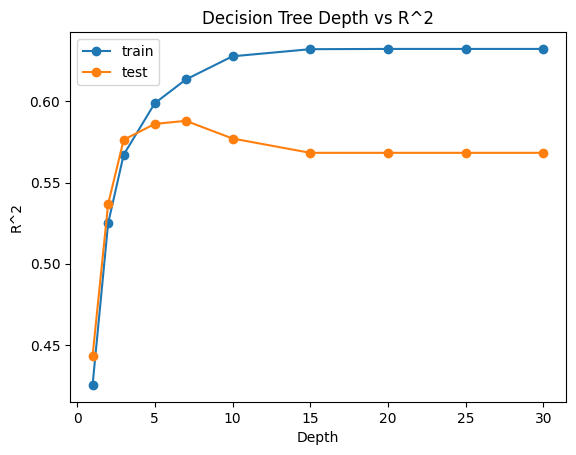

'{"depth":{"0":1,"1":2,"2":3,"3":5,"4":7,"5":10,"6":15,"7":20,"8":25,"9":30},"train":{"0":0.4252952837,"1":0.524881256,"2":0.5671421268,"3":0.5988606165,"4":0.6135036914,"5":0.6277975133,"6":0.632180167,"7":0.6323415904,"8":0.6323415904,"9":0.6323415904},"test":{"0":0.4432331568,"1":0.5367285815,"2":0.5763223391,"3":0.5861466271,"4":0.588022776,"5":0.5771425902,"6":0.5683139619,"7":0.5683203389,"8":0.5683203389,"9":0.5683203389}}'

In [18]:
#q10: How does tree depth impact the quality of predictions?

ax = q10_df.plot(x="depth", y=["train", "test"], marker="o")
ax.set_xlabel("Depth")
ax.set_ylabel("R^2")
ax.set_title("Decision Tree Depth vs R^2")
plt.show()

q10_json = q10_df.to_json()
print(q10_json)